# AI Interview Simulator — Dataset Exploratory Data Analysis
**Project:** Multi-Agent AI Interview Simulator  
**Dataset:** Custom-curated Interview Q&A Dataset (252 samples)  
**Purpose:** Understand dataset structure, distribution, and quality before model evaluation

## 1. Imports and Setup

In [2]:
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# Consistent style across all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

DATASET_PATH = 'combined_dataset.json'  # adjust if filename differs
OUTPUT_DIR   = 'eda_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load and Inspect Raw Data

In [3]:
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f'Total samples loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Total samples loaded: 260
Columns: ['id', 'role', 'type', 'difficulty', 'question', 'ideal_answer', 'generated_by', 'timestamp']


,id,role,type,difficulty,question,ideal_answer,generated_by,timestamp
0,software_engineer_hr_easy_0001,Software Engineer,HR,easy,Tell me about a time you had to collaborate wi...,On a project involving a new user interface fo...,gemma2:2b,2026-05-08T12:29:22.186831
1,software_engineer_hr_easy_0002,Software Engineer,HR,easy,Describe a time you encountered a technical ch...,During a recent project developing a real-time...,gemma2:2b,2026-05-08T12:29:44.967217
2,software_engineer_hr_medium_0003,Software Engineer,HR,medium,Tell me about a time you had to work with a te...,"During my previous role at [Company], I worked...",gemma2:2b,2026-05-08T12:30:05.742358


## 3. Basic Dataset Statistics

In [4]:
print('=== Dataset Overview ===')
print(f"Total Samples       : {len(df)}")
print(f"Unique Roles        : {df['role'].nunique()} \u2192 {df['role'].unique().tolist()}")
print(f"Interview Types     : {df['type'].unique().tolist()}")
print(f"Difficulty Levels   : {df['difficulty'].unique().tolist()}")
print(f"Missing Values      :\n{df.isnull().sum()}")
print(f"\nGenerated By        : {df['generated_by'].unique().tolist()}")

=== Dataset Overview ===
Total Samples       : 260
Unique Roles        : 10 → ['Software Engineer', 'Data Scientist', 'Machine Learning Engineer', 'Frontend Developer', 'Backend Developer', 'DevOps Engineer', 'Product Manager', 'UX Designer', 'Data Analyst', 'Cybersecurity Analyst']
Interview Types     : ['HR', 'Technical']
Difficulty Levels   : ['easy', 'medium', 'hard']
Missing Values      :
id              0
role            0
type            0
difficulty      0
question        0
ideal_answer    0
generated_by    0
timestamp       0
dtype: int64

Generated By        : ['gemma2:2b', 'llama3.2:latest', 'phi3:latest']


## 4. Preprocessing

In [5]:
# ── Text length features ─────────────────────────────────────────
df['question_len_chars']  = df['question'].str.len()
df['answer_len_chars']    = df['ideal_answer'].str.len()
df['question_len_words']  = df['question'].str.split().str.len()
df['answer_len_words']    = df['ideal_answer'].str.split().str.len()

# ── Ordered categorical for clean plots ──────────────────────────
diff_order = ['easy', 'medium', 'hard']
df['difficulty'] = pd.Categorical(df['difficulty'], categories=diff_order, ordered=True)

# ── Sentence count (rough split on . ? !) ────────────────────────
df['answer_sentences'] = df['ideal_answer'].apply(
    lambda t: len(re.split(r'[.!?]+', t.strip())) if isinstance(t, str) else 0
)

print('Preprocessing complete. New columns added:')
print(df[['question_len_words','answer_len_words','answer_sentences']].describe().round(2))

Preprocessing complete. New columns added:
       question_len_words  answer_len_words  answer_sentences
count              260.00            260.00            260.00
mean                37.24            141.43              6.88
std                 12.49             47.39              1.93
min                 13.00             79.00              4.00
25%                 28.00            106.75              6.00
50%                 36.00            129.00              6.00
75%                 45.00            165.25              8.00
max                 91.00            326.00             23.00


## 5. Distribution of Difficulty Levels

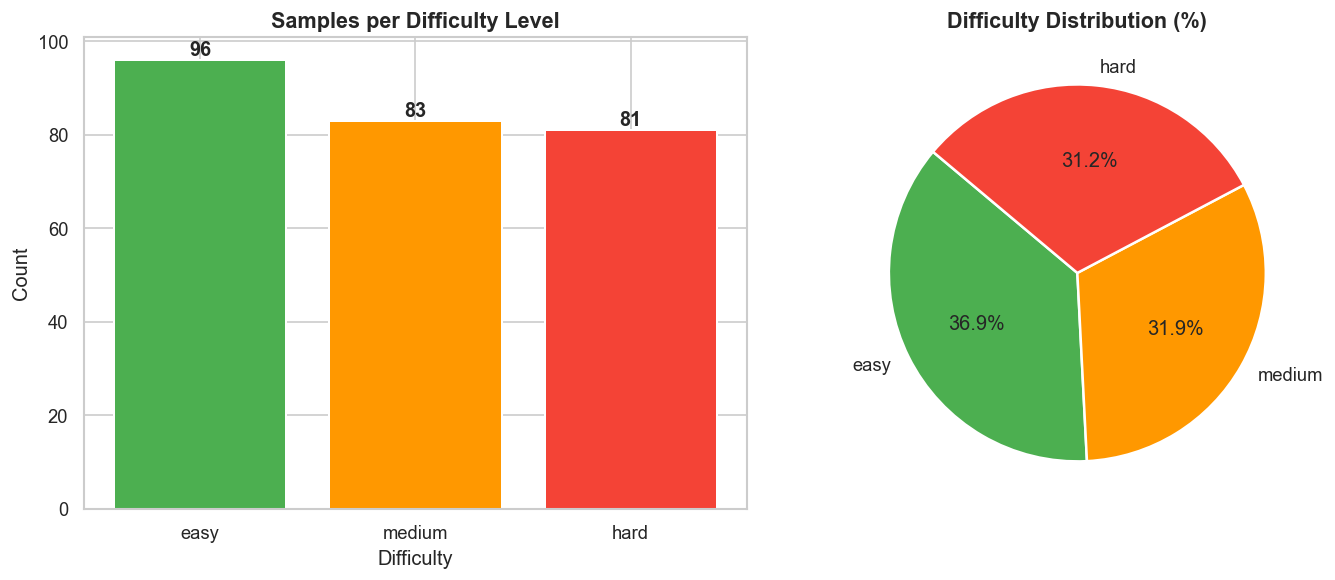

difficulty
easy      96
medium    83
hard      81


In [6]:
counts = df['difficulty'].value_counts().reindex(diff_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4CAF50', '#FF9800', '#F44336']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_title('Samples per Difficulty Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Difficulty'); axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Difficulty Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/difficulty_distribution.png')
plt.show()
print(counts.to_string())

## 6. Distribution of Interview Types

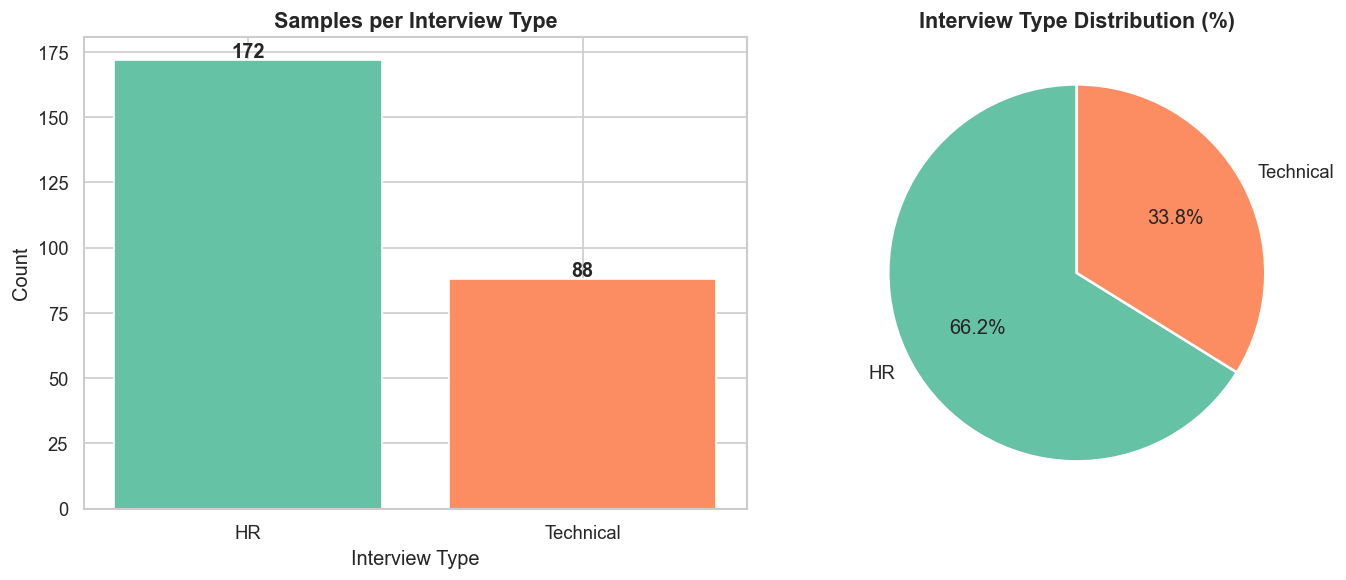

In [7]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

type_colors = sns.color_palette('Set2', len(type_counts))
axes[0].bar(type_counts.index, type_counts.values, color=type_colors, edgecolor='white')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_title('Samples per Interview Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Interview Type'); axes[0].set_ylabel('Count')

axes[1].pie(type_counts.values, labels=type_counts.index, colors=type_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Interview Type Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/type_distribution.png')
plt.show()

## 7. Distribution of Roles

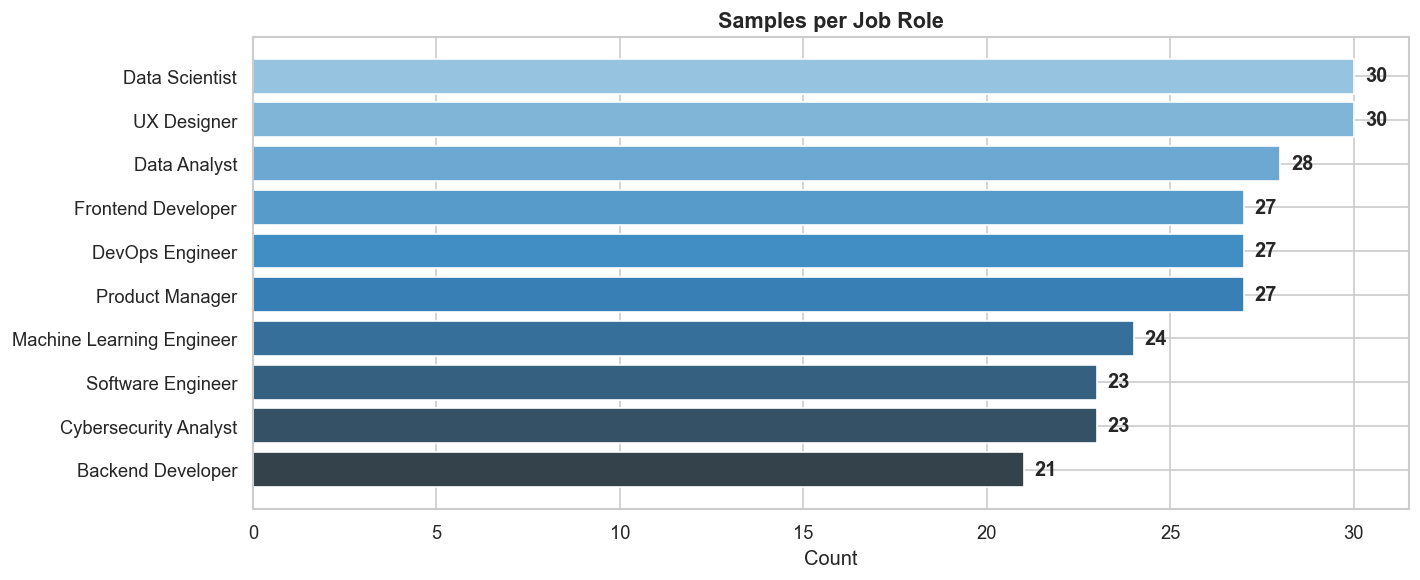

In [8]:
role_counts = df['role'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(role_counts.index, role_counts.values,
               color=sns.color_palette('Blues_d', len(role_counts)),
               edgecolor='white')
for bar, val in zip(bars, role_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')
ax.set_title('Samples per Job Role', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/role_distribution.png')
plt.show()

## 8. Cross-Analysis: Role × Difficulty × Type

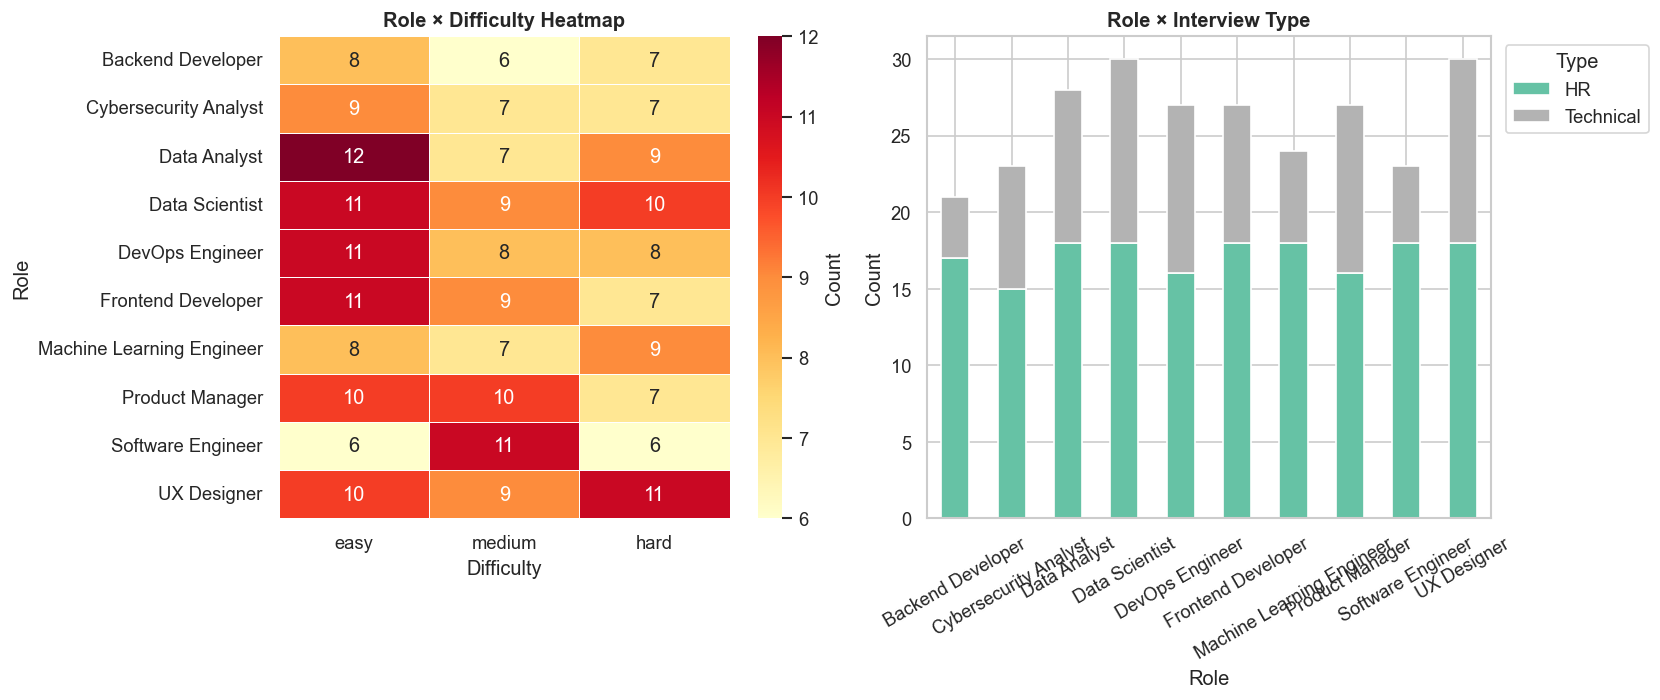

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap: Role × Difficulty
pivot1 = df.groupby(['role','difficulty']).size().unstack(fill_value=0).reindex(columns=diff_order)
sns.heatmap(pivot1, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Role \u00d7 Difficulty Heatmap', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Difficulty'); axes[0].set_ylabel('Role')

# Stacked bar: Role × Type
pivot2 = df.groupby(['role','type']).size().unstack(fill_value=0)
pivot2.plot(kind='bar', stacked=True, ax=axes[1],
            colormap='Set2', edgecolor='white')
axes[1].set_title('Role \u00d7 Interview Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Role'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Type', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cross_analysis.png')
plt.show()

## 9. Question and Answer Length Analysis

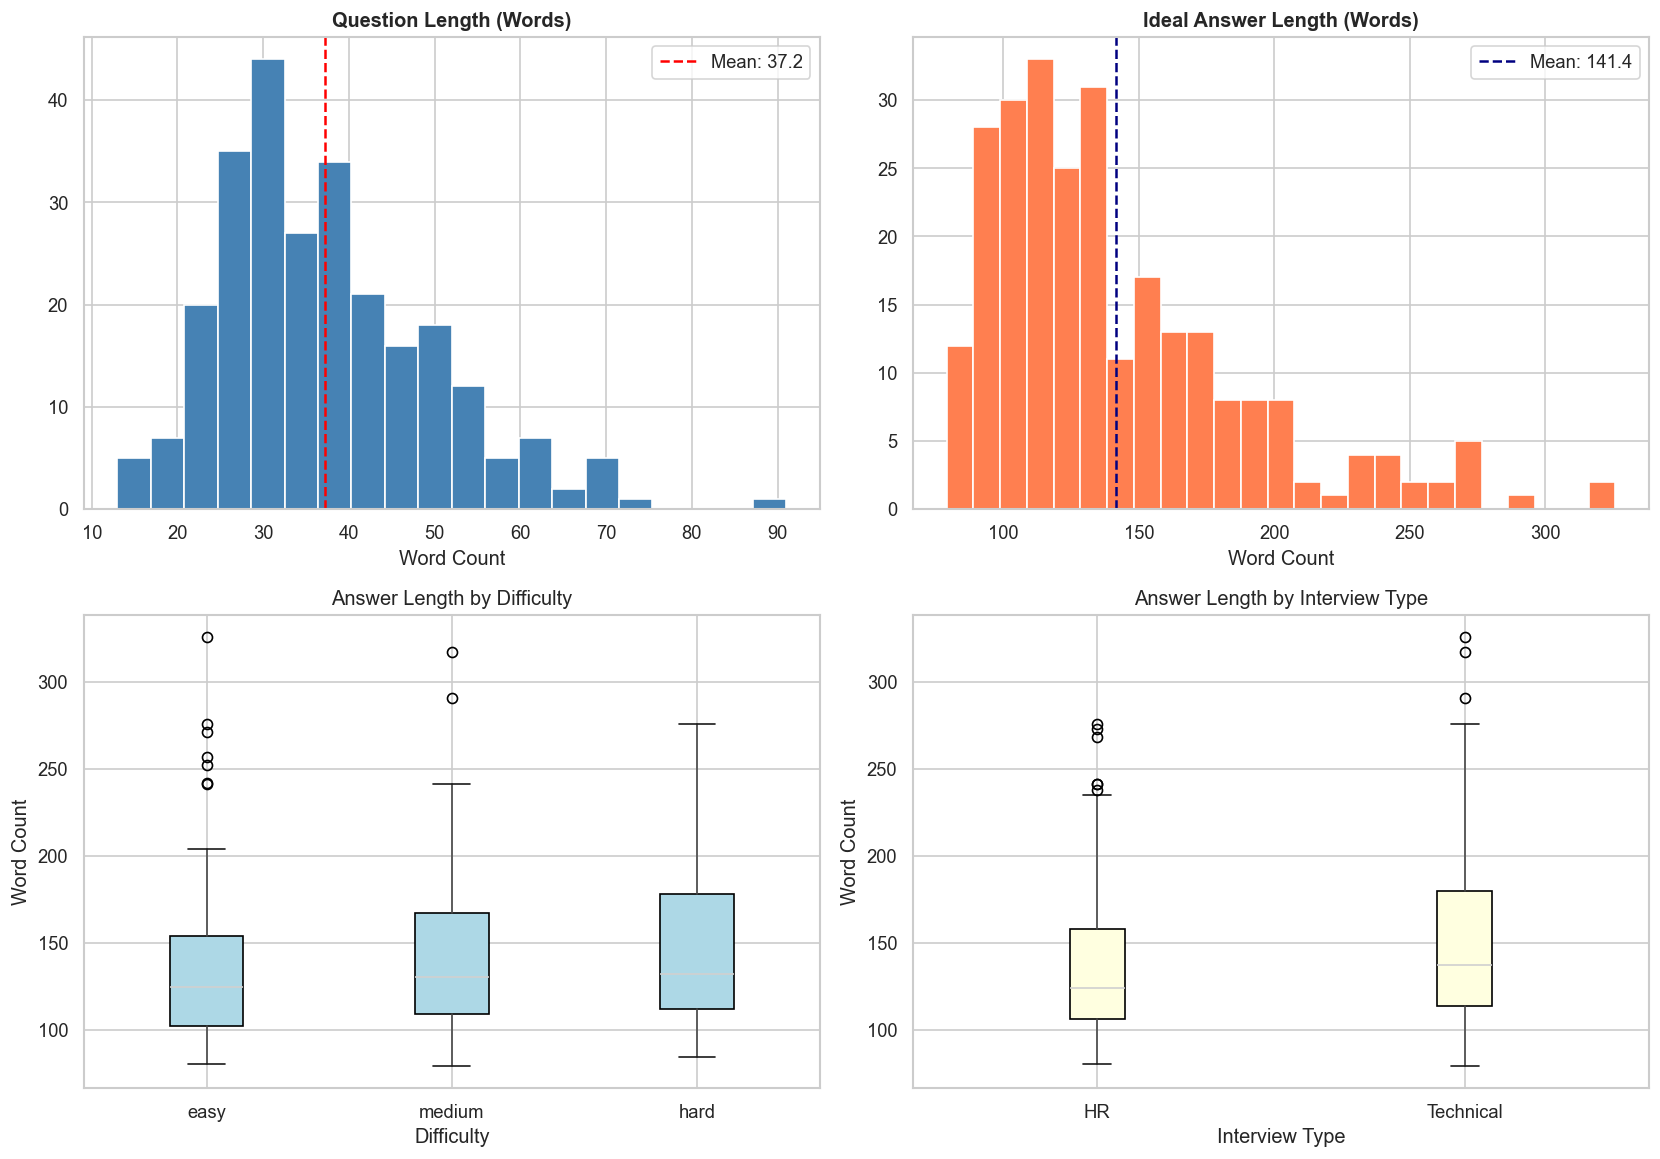


=== Length Statistics ===
       question_len_words  answer_len_words  answer_sentences
count              260.00            260.00            260.00
mean                37.24            141.43              6.88
std                 12.49             47.39              1.93
min                 13.00             79.00              4.00
25%                 28.00            106.75              6.00
50%                 36.00            129.00              6.00
75%                 45.00            165.25              8.00
max                 91.00            326.00             23.00


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Question word length histogram
axes[0,0].hist(df['question_len_words'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].axvline(df['question_len_words'].mean(), color='red', linestyle='--', label=f"Mean: {df['question_len_words'].mean():.1f}")
axes[0,0].set_title('Question Length (Words)', fontweight='bold')
axes[0,0].set_xlabel('Word Count'); axes[0,0].legend()

# Answer word length histogram
axes[0,1].hist(df['answer_len_words'], bins=25, color='coral', edgecolor='white')
axes[0,1].axvline(df['answer_len_words'].mean(), color='navy', linestyle='--', label=f"Mean: {df['answer_len_words'].mean():.1f}")
axes[0,1].set_title('Ideal Answer Length (Words)', fontweight='bold')
axes[0,1].set_xlabel('Word Count'); axes[0,1].legend()

# Answer length by difficulty
df.boxplot(column='answer_len_words', by='difficulty', ax=axes[1,0],
           positions=range(len(diff_order)),
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
axes[1,0].set_xticklabels(diff_order)
axes[1,0].set_title('Answer Length by Difficulty', fontweight='bold')
axes[1,0].set_xlabel('Difficulty'); axes[1,0].set_ylabel('Word Count')
plt.sca(axes[1,0]); plt.title('Answer Length by Difficulty')

# Answer length by type
df.boxplot(column='answer_len_words', by='type', ax=axes[1,1],
           patch_artist=True,
           boxprops=dict(facecolor='lightyellow'))
axes[1,1].set_title('Answer Length by Interview Type', fontweight='bold')
axes[1,1].set_xlabel('Interview Type'); axes[1,1].set_ylabel('Word Count')
plt.sca(axes[1,1]); plt.title('Answer Length by Interview Type')

plt.suptitle('')  # remove auto-generated suptitle from boxplot
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/length_analysis.png')
plt.show()

print('\n=== Length Statistics ===')
print(df[['question_len_words','answer_len_words','answer_sentences']].describe().round(2))

## 10. Word Clouds — Questions vs Ideal Answers

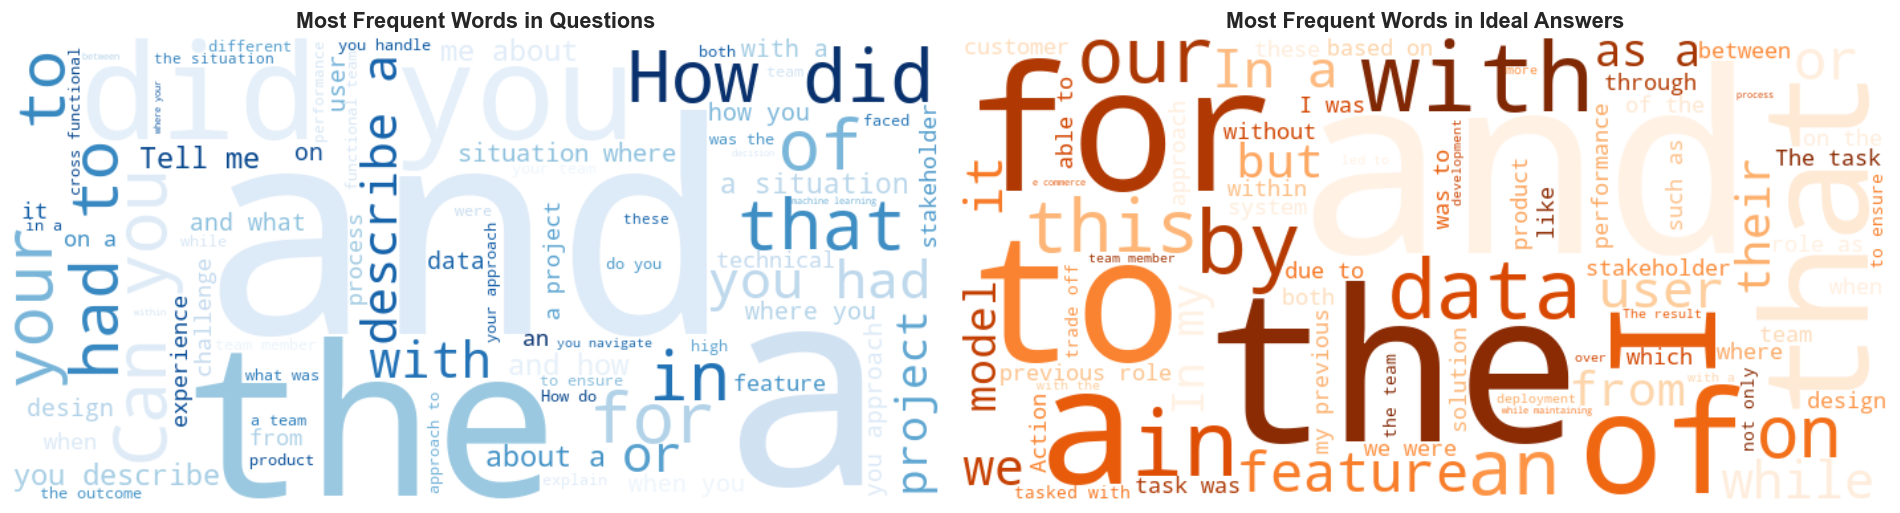

In [11]:
stopwords_extra = {'one', 'would', 'also', 'well', 'get', 'us', 'use', 'way',
                   'make', 'even', 'two', 'new', 'time', 'work', 'used', 'using'}

q_text  = ' '.join(df['question'].dropna())
a_text  = ' '.join(df['ideal_answer'].dropna())

wc_q = WordCloud(width=700, height=350, background_color='white',
                 colormap='Blues', max_words=80,
                 stopwords=stopwords_extra).generate(q_text)

wc_a = WordCloud(width=700, height=350, background_color='white',
                 colormap='Oranges', max_words=80,
                 stopwords=stopwords_extra).generate(a_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_q, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words in Questions', fontsize=13, fontweight='bold')

axes[1].imshow(wc_a, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words in Ideal Answers', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/wordclouds.png')
plt.show()

## 11. Word Clouds by Difficulty Level

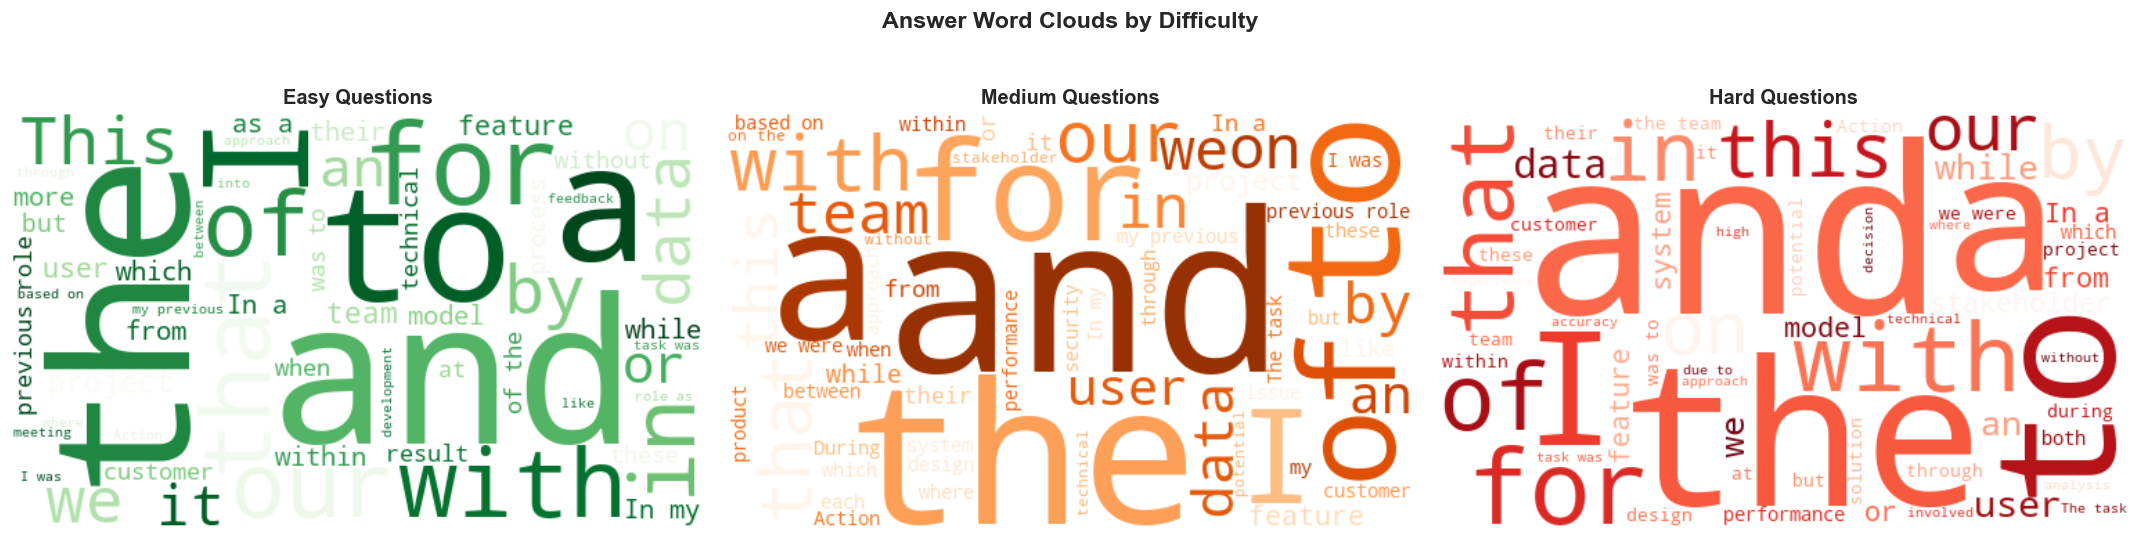

In [12]:
cmaps = {'easy': 'Greens', 'medium': 'Oranges', 'hard': 'Reds'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, level in zip(axes, diff_order):
    subset_text = ' '.join(df[df['difficulty'] == level]['ideal_answer'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmaps[level], max_words=60,
                   stopwords=stopwords_extra).generate(subset_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{level.capitalize()} Questions', fontsize=12, fontweight='bold')

plt.suptitle('Answer Word Clouds by Difficulty', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/wordclouds_by_difficulty.png')
plt.show()

## 12. Top 20 Most Frequent Question Keywords

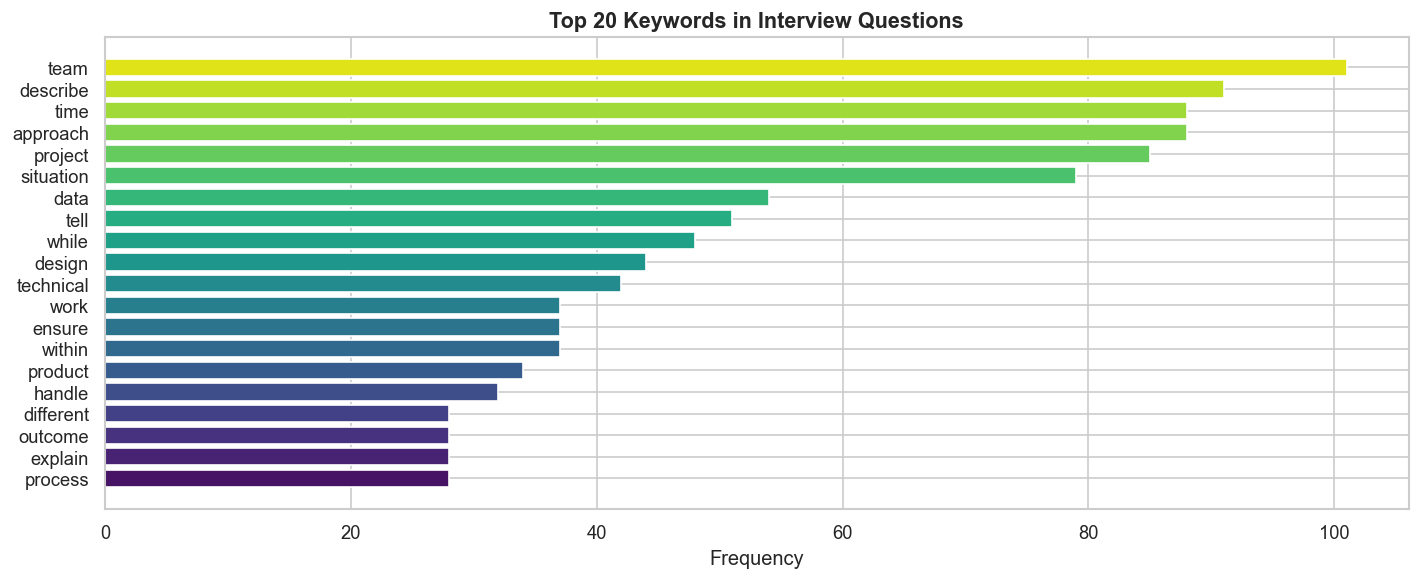

In [13]:
from collections import Counter
import string

common_stopwords = {
    'a','an','the','and','or','but','in','on','at','to','for','of','with',
    'is','was','are','were','be','been','have','has','had','do','did','does',
    'you','your','i','my','we','our','they','their','it','its','this','that',
    'what','how','when','where','why','which','who','would','could','should',
    'if','about','from','by','as','not','can','more','some','any','all',
    'one', 'two', 'new', 'also', 'will', 'just', 'into', 'up'
}

def tokenize(text):
    tokens = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    return [t for t in tokens if t not in common_stopwords and len(t) > 2]

all_q_tokens = [tok for q in df['question'].dropna() for tok in tokenize(q)]
top20 = Counter(all_q_tokens).most_common(20)
words, freqs = zip(*top20)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(list(words)[::-1], list(freqs)[::-1],
        color=sns.color_palette('viridis', 20))
ax.set_title('Top 20 Keywords in Interview Questions', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top_keywords.png')
plt.show()

## 13. Dataset Summary Table

In [14]:
summary = pd.DataFrame({
    'Metric': [
        'Total Samples',
        'Unique Roles',
        'Interview Types',
        'Difficulty Levels',
        'Avg Question Length (words)',
        'Avg Answer Length (words)',
        'Min Answer Length (words)',
        'Max Answer Length (words)',
        'Avg Answer Sentences',
        'Missing Values',
    ],
    'Value': [
        len(df),
        df['role'].nunique(),
        ', '.join(df['type'].unique()),
        'easy / medium / hard',
        f"{df['question_len_words'].mean():.1f}",
        f"{df['answer_len_words'].mean():.1f}",
        df['answer_len_words'].min(),
        df['answer_len_words'].max(),
        f"{df['answer_sentences'].mean():.1f}",
        df.isnull().sum().sum(),
    ]
})

print('=== Dataset Summary ===')
print(summary.to_string(index=False))

# Save clean CSV for use in evaluation notebook
df.to_csv('interview_dataset_processed.csv', index=False)
print('\nProcessed dataset saved to interview_dataset_processed.csv')

=== Dataset Summary ===
                     Metric                Value
              Total Samples                  260
               Unique Roles                   10
            Interview Types        HR, Technical
          Difficulty Levels easy / medium / hard
Avg Question Length (words)                 37.2
  Avg Answer Length (words)                141.4
  Min Answer Length (words)                   79
  Max Answer Length (words)                  326
       Avg Answer Sentences                  6.9
             Missing Values                    0

Processed dataset saved to interview_dataset_processed.csv


## 14. Key Observations

Document your findings here (fill in after running):

1. **Dataset Size:** 252 samples spanning multiple roles, difficulty levels, and interview types — sufficient for comparative model evaluation.
2. **Balance:** *(note if easy/medium/hard are roughly balanced or skewed)*
3. **Answer Length:** Hard questions tend to have longer, more detailed ideal answers than easy ones — consistent with real interview expectations.
4. **Question Keywords:** Common themes include *team, project, experience, challenge, approach* — confirming behavioral/STAR-format focus.
5. **No Missing Values:** Dataset is complete with no null fields, requiring no imputation.
6. **Custom Dataset:** This dataset was curated specifically for this project and is not publicly available — enabling novel evaluation benchmarking.